## Business Understanding


#### Introduction
Seasonal influenza is a recurring public health concern that causes significant illness and deaths each year. Vaccination is one of the most effective ways to prevent infection and reduce the spread of the disease. However, vaccination uptake varies across different population groups. Understanding the factors that influence individuals’ decisions to receive seasonal influenza vaccination is important for improving public health strategies and increasing immunization coverage.

#### Problem Statement
Seasonal influenza continues to affect millions of people every year, yet vaccination uptake remains inconsistent across different population groups. Many individuals choose not to receive the vaccine due to factors such as personal beliefs, perceived risk of illness, healthcare access, or lack of awareness. These variations in behavior make it difficult for public health organizations to identify which groups are less likely to get vaccinated and why. Without clear insights into these influencing factors, efforts to improve vaccination coverage may not effectively reach the populations that need them most. Therefore, analyzing data on demographic characteristics, health behaviors, and public perceptions is essential to better understand vaccination patterns and support more targeted public health interventions.

#### Project goal
The primary goal of this project is to develop a robust predictive model that accurately classifies individuals based on their probability of receiving the seasonal influenza vaccine, in order to enable targeted, data-driven public health interventions that increase vaccination coverage.

#### Objective
To develop a highly accurate predictive model that identifies individuals likely to forgo seasonal influenza vaccination, enabling targeted public health interventions.

### Business Stakeholders
1. Policy and Advisory
- World Health Organization(WHO)
- National Ministries
- Regulatory Agencies

2. Manufactures and Supply
- Pharma companies
- Distributers and logistic providers
- Research Institutions

3.Implementation and Recipients
- Healthcare workers(doctors,nurses)
- public health agencies
- priority groups: pregnanat women, 65+ chronic conditions

#### Data Description
The datasets used for this project were downloaded from Driven Data. The original data source is the National 2009 H1N1 Flu Survey NHFS and it contains information on the social,economic and demographic backgrounds of the respondents as well as their opinions on the H1N1 and seasonal flu vaccines. The datasets have been divided into the training set features and the training set labels. The training data has 26707 rows and 36 columns.

## Data Understanding

The dataset contains information about individuals' characteristics and opinions related to seasonal flu and H1N1 vaccination, comprising 36 columns.

1. Identifiers: A unique respondent_id for each entry.
2. Target Variables: Two binary variables indicating whether the respondent received the h1n1_vaccine and/or seasonal_vaccine (0 = No, 1 = Yes).
3. Demographic Data: Includes age_group, education, race, sex, income_poverty, marital_status, and rent_or_own.
4. Behavioral Information: Features such as behavioral_antiviral_meds, behavioral_avoidance, behavioral_face_mask, behavioral_wash_hands, behavioral_large_gatherings, behavioral_outside_home, and behavioral_touch_face describe preventive actions.
5. Doctor Recommendations: Specifies if doctor_recc_h1n1 or doctor_recc_seasonal vaccines were advised by a doctor.
6. Opinions and Perceptions: Gathers respondent's views on vaccine effectiveness, risk of illness, and worry about getting sick from the vaccine for both h1n1 and seasonal flu. These are ordinal scales (1-5).
Variable Types: Most variables are binary (0/1), while others are categorical or ordinal.

*Data suitability*

This survey data, captures individuals' demographics, behaviors, and opinions, making it highly suitable for understanding flu vaccination drivers. The data's breadth allows for building a predictive model capable of segmenting populations for targeted public health interventions.

*Feature Inclusion*

The inclusion of the 35 features in the analysis is justified by their direct relevance to established factors influencing health behaviors and vaccination uptake.

*Data Limitations*

Despite its suitability, the dataset presents certain limitations that have implications for the project.

- As survey data, it relies on self-reporting, which can be subject to recall bias or social desirability bias.
- The categorical nature of many variables requires careful preprocessing.
- The dataset represents a snapshot in time, meaning it may not fully capture dynamic changes in public health sentiment or emerging behavioral trends.

### 3.1 Importing Libraries and Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, RocCurveDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

In [2]:
## Load datasets 
features = pd.read_csv(r"Data\training_set_features.csv",index_col='respondent_id')
labels = pd.read_csv(r"Data\training_set_labels.csv",index_col='respondent_id')
test_features = pd.read_csv(r"Data\test_set_features.csv",index_col='respondent_id')
# shape and alignment
print("Train Features Shape:", features.shape)
print("Train Labels Shape:", labels.shape)
print("Test Features Shape:", test_features.shape)

# Preview the first few rows
features.head()

Train Features Shape: (26707, 35)
Train Labels Shape: (26707, 2)
Test Features Shape: (26708, 35)


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
respondent_id,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb


In [3]:
#checking missing values
features.isnull().sum().sort_values(ascending=False).head() 


employment_occupation    13470
employment_industry      13330
health_insurance         12274
income_poverty            4423
doctor_recc_h1n1          2160
dtype: int64

In [4]:
#Display the first few rows of the training labels
print(labels.head())

               h1n1_vaccine  seasonal_vaccine
respondent_id                                
0                         0                 0
1                         0                 1
2                         0                 0
3                         0                 1
4                         0                 0


In [5]:
#Display the first few rows of the test features
test_features.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
respondent_id,,,,,,,,,,,,,,,,,,,,,
26707,2.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,"> $75,000",Not Married,Rent,Employed,mlyzmhmf,"MSA, Not Principle City",1.0,0.0,atmlpfrs,hfxkjkmi
26708,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,Non-MSA,3.0,0.0,atmlpfrs,xqwwgdyp
26709,2.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,...,"> $75,000",Married,Own,Employed,lrircsnp,Non-MSA,1.0,0.0,nduyfdeo,pvmttkik
26710,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,lrircsnp,"MSA, Not Principle City",1.0,0.0,NaN,NaN
26711,3.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,lzgpxyit,Non-MSA,0.0,1.0,fcxhlnwr,mxkfnird


### 3.2 Merging the training Features and labels

In [6]:
# merging the training features and labels into a single DataFrame
data = features.merge(labels, on="respondent_id").copy()

# merged training DataFrame
data.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [7]:
data.to_csv("merged_flu_dataset.csv", index=False)

### 3.3 Exploring the Data

In [8]:
#shape of the training DataFrame
data.shape

(26707, 37)

In [9]:
#checking datatypes and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26707 entries, 0 to 26706
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 26615 non-null  float64
 1   h1n1_knowledge               26591 non-null  float64
 2   behavioral_antiviral_meds    26636 non-null  float64
 3   behavioral_avoidance         26499 non-null  float64
 4   behavioral_face_mask         26688 non-null  float64
 5   behavioral_wash_hands        26665 non-null  float64
 6   behavioral_large_gatherings  26620 non-null  float64
 7   behavioral_outside_home      26625 non-null  float64
 8   behavioral_touch_face        26579 non-null  float64
 9   doctor_recc_h1n1             24547 non-null  float64
 10  doctor_recc_seasonal         24547 non-null  float64
 11  chronic_med_condition        25736 non-null  float64
 12  child_under_6_months         25887 non-null  float64
 13  health_worker   

In [10]:
# Numerical features summary
data.describe()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,24547.000000,...,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000,26707.000000
mean,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,0.220312,...,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454,0.465608
std,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,0.414466,...,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052,0.498825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,...,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,0.000000,...,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,...,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000


In [11]:
# Categorical features summary
data.describe(include='object')

,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,employment_industry,employment_occupation
count,26707,25300,26707,26707,22284,25299,24665,25244,26707,26707,13377,13237
unique,5,4,4,2,3,2,2,3,10,3,21,23
top,65+ Years,College Graduate,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,lzgpxyit,"MSA, Not Principle City",fcxhlnwr,xtkaffoo
freq,6843,10097,21222,15858,12777,13555,18736,13560,4297,11645,2468,1778


In [12]:
# Checking for missing Values
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

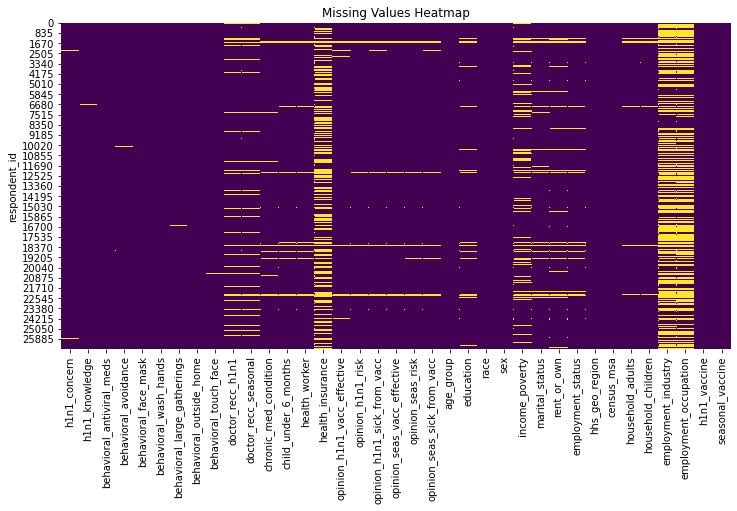

In [13]:
# Visualizing missing values with a heatmap
plt.figure(figsize=(12,6))
sns.heatmap(data.isnull(), cbar = False,cmap = "viridis")
plt.title("Missing Values Heatmap")
plt.show()

### 3.4 Target Variable Distribution

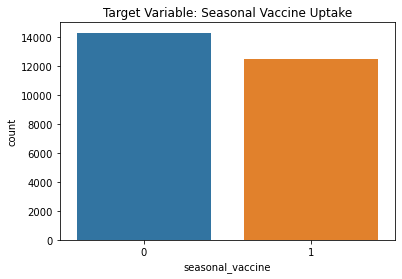

0    53.439173
1    46.560827
Name: seasonal_vaccine, dtype: float64

In [14]:
# Target Variable (seasonal_vaccine) distribution
sns.countplot(x='seasonal_vaccine', data=data)
plt.title("Target Variable: Seasonal Vaccine Uptake")
plt.show()                            

data['seasonal_vaccine'].value_counts(normalize=True)* 100 # normalize the counts to percentages

- This shows a class distribution of approxiately 53% vs. 47%, which indicates a fairly balanced dataset and special resampling techniques like SMOTE or undersampling are not necessary.

### 3.5 Univariate Feature Distribution
#### Distribution of Several Feature Indipendently

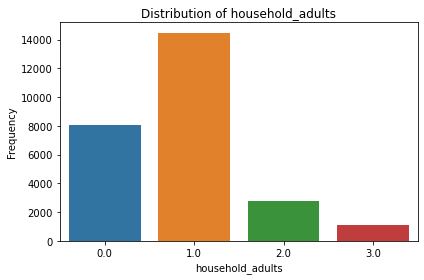

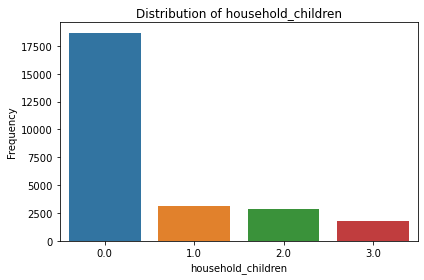

In [15]:
# Select representative features
num_features = ['household_adults', 'household_children']
cat_features = ['age_group', 'race', 'income_poverty']
bin_features = ['behavioral_face_mask', 'behavioral_wash_hands']

# 1. Plot numerical features
for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=data)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

- The majority of households have one adult.
- Most households have no children, with the frequency sharply decreasing as the number of children increases.

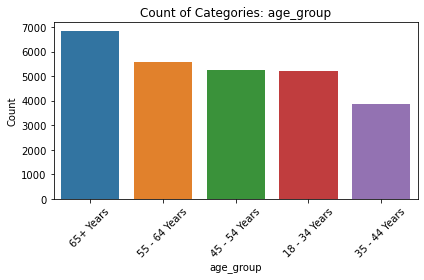

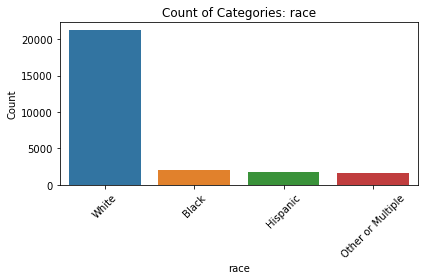

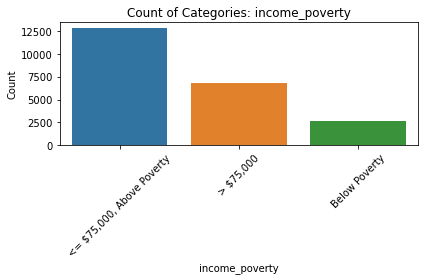

In [16]:
# 2. Plot categorical features
for col in cat_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=data, x=col, order=data[col].value_counts().index)
    plt.title(f'Count of Categories: {col}')
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

- The largest group is 65+ years
- The majority of respondents are white
- The most individuals earn income above the poverty
threshold of $75,000.

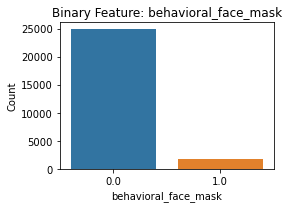

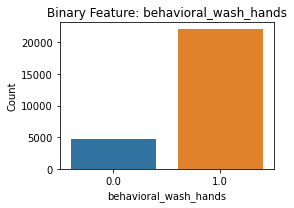

In [17]:
# 3. Plot binary features
for col in bin_features:
    plt.figure(figsize=(4, 3))
    sns.countplot(data=data, x=col)
    plt.title(f'Binary Feature: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

- Most respondents do not wear mask.
- The majority of respondents report washing their hands frequently.

### 3.6 Bivariate Feature Analysis

#### Feature vs Target

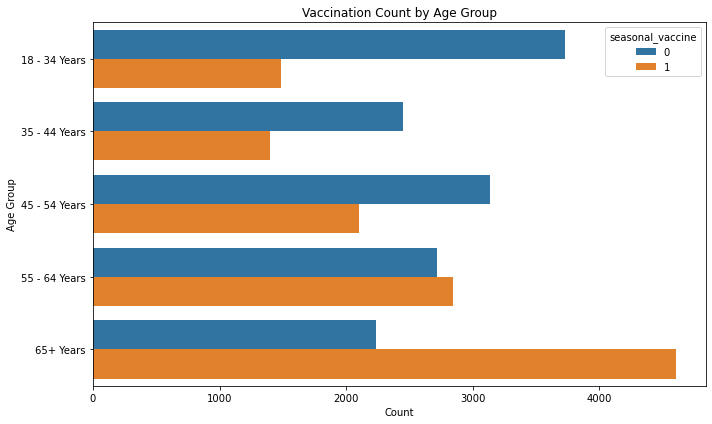

In [18]:
# age group distribution - See vaccination rates across age groups
plt.figure(figsize=(10, 6))
# Making legend labels strings 
plot_data = data.copy()
plot_data['seasonal_vaccine'] = plot_data['seasonal_vaccine'].astype(str)

age_order = ['18 - 34 Years', '35 - 44 Years', '45 - 54 Years', '55 - 64 Years', '65+ Years']
sns.countplot(data=plot_data, y='age_group', hue='seasonal_vaccine', order=age_order)
plt.title('Vaccination Count by Age Group')
plt.xlabel('Count')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

- Persons aged 65 years and above have the highest vaccine count 

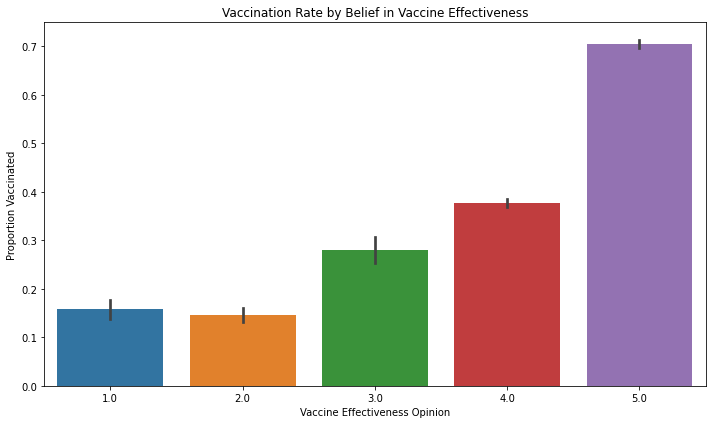

In [19]:
#  Check if belief in effectiveness influences uptake
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='opinion_seas_vacc_effective', y='seasonal_vaccine')
plt.title('Vaccination Rate by Belief in Vaccine Effectiveness')
plt.xlabel('Vaccine Effectiveness Opinion')
plt.ylabel('Proportion Vaccinated')
plt.tight_layout()
plt.show()

The plot shows a positive correlation between belief in vaccine effectiveness and vaccination uptake. Respondents with the highest vaccination rate
are the one who believe the vaccine is very effective(5).

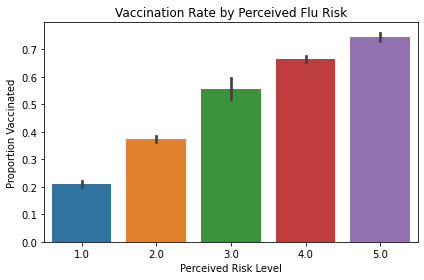

In [20]:
# Measure impact of perceived risk
sns.barplot(data=data, x='opinion_seas_risk', y='seasonal_vaccine')
plt.title('Vaccination Rate by Perceived Flu Risk')
plt.xlabel('Perceived Risk Level')
plt.ylabel('Proportion Vaccinated')
plt.tight_layout()
plt.show()

This plot shows that risk perception is a strong motivator for vaccine uptake.As individuals' perceived risk of catching the flu increases,the likelihood of getting vaccinated also increases.

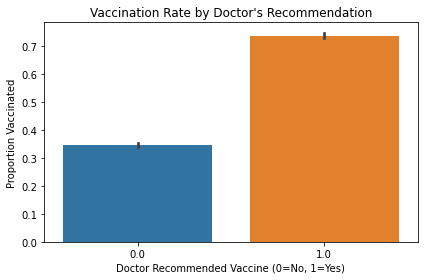

In [21]:
# How much does a doctor’s recommendation matter?
sns.barplot(data=data, x='doctor_recc_seasonal', y='seasonal_vaccine')
plt.title("Vaccination Rate by Doctor's Recommendation")
plt.xlabel("Doctor Recommended Vaccine (0=No, 1=Yes)")
plt.ylabel('Proportion Vaccinated')
plt.tight_layout()
plt.show()

Respondents who received a doctor's recommendation had a significantly higher vaccination rate compared to those who did not receive.


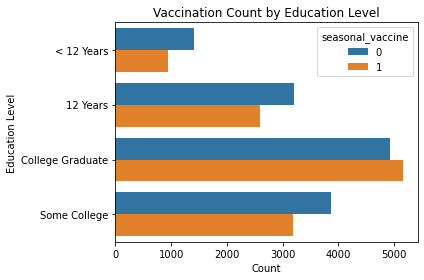

In [22]:
# Understand vaccination trends across different education levels
sns.countplot(data=plot_data, y='education', hue='seasonal_vaccine')
plt.title('Vaccination Count by Education Level')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.tight_layout()
plt.show()

Education level correlates with vaccination ,college graduates have a slightly hinger vaccination rates.

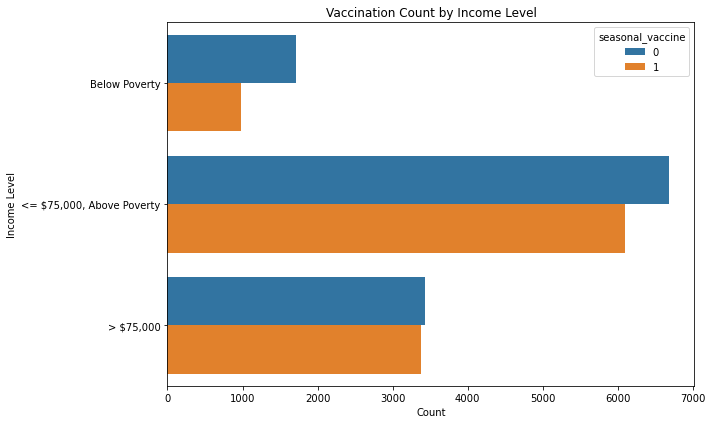

In [23]:
# income - Understand vaccination trends across different income levels
plt.figure(figsize=(10, 6))
sns.countplot(data=plot_data, y='income_poverty', hue='seasonal_vaccine')
plt.title('Vaccination Count by Income Level')
plt.xlabel('Count')
plt.ylabel('Income Level')
plt.tight_layout()
plt.show()

Those with income level above threshold level (75,000) are highly vaccinated.

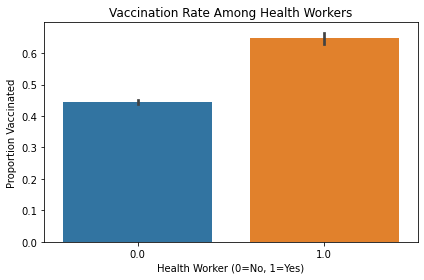

In [24]:
# Does being a health worker affect vaccine uptake?
sns.barplot(data=data, x='health_worker', y='seasonal_vaccine')
plt.title('Vaccination Rate Among Health Workers')
plt.xlabel('Health Worker (0=No, 1=Yes)')
plt.ylabel('Proportion Vaccinated')
plt.tight_layout()
plt.show()

- Health workers have higher likelihood of being vaccinated.

In [25]:
summary = data.groupby('seasonal_vaccine')[['opinion_seas_vacc_effective', 
                                          'opinion_seas_risk', 
                                          'doctor_recc_seasonal']].mean()
print(summary)

                  opinion_seas_vacc_effective  opinion_seas_risk  \
seasonal_vaccine                                                   
0                                    3.657897           2.213339   
1                                    4.445994           3.296305   

                  doctor_recc_seasonal  
seasonal_vaccine                        
0                             0.164453  
1                             0.511992  


The results indicate that perception of vaccine effectiveness, perceived risk of illness, and doctor recommendations are key factors influencing seasonal influenza vaccination uptake. Individuals who trust the vaccine, feel at risk of infection, and receive medical advice from healthcare professionals are significantly more likely to get vaccinated.

## 4. Data Preparation

##### Multicollinearity Check

In [26]:
# 1. Initial categorical/numeric separation
categorical_cols = data.select_dtypes(include='object').columns
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

print("== Data Overview ==")
print(f"Total columns: {len(data.columns)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"Numeric columns: {len(numeric_cols)}")
print("-" * 50)

# 2. One-hot encode categorical columns
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
print(f"After one-hot encoding: {data_encoded.shape[1]} columns")

# 3. Check initial correlations (on original numeric columns)
print("\n=Initial Correlation Check =")
correlation_matrix_original = data[numeric_cols].corr()
print("Original numeric columns correlation matrix shape:", correlation_matrix_original.shape)

# 4. Check correlations on encoded data and remove highly correlated features
print("\n= Checking for Highly Correlated Features in Encoded Data =")
correlation_matrix = data_encoded.corr()

# Find and remove highly correlated features (threshold > 0.7)
columns_to_drop = []
threshold = 0.7

print(f"Looking for correlations > {threshold}...")
found_high_correlation = False
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.loc[col1, col2]
        
        if abs(corr_value) > threshold:
            print(f"  {col1} and {col2}: {corr_value:.4f}")
            columns_to_drop.append(col2)  # Mark the second column for removal
            found_high_correlation = True

if not found_high_correlation:
    print("  No pairs with correlation greater than 0.7 found!")
else:
    print(f"\nFound {len(columns_to_drop)} columns to potentially drop")

# 5. Check for PERFECT correlations (1.0) - stricter check
print("\n= Checking for Perfect Correlations (1.0) =")
perfect_corr_columns = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.loc[col1, col2]
        
        if abs(corr_value) > 0.99:  # Close to perfect correlation
            print(f"  PERFECT: {col1} and {col2}: {corr_value:.4f}")
            perfect_corr_columns.append(col2)  # Mark the second column for removal

if perfect_corr_columns:
    print(f"Found {len(perfect_corr_columns)} perfectly correlated columns")
    columns_to_drop.extend(perfect_corr_columns)

# 6. Remove duplicates and drop columns
columns_to_drop = list(set(columns_to_drop)) 
print(f"\n Removing Columns")
print(f"Total columns to remove: {len(columns_to_drop)}")

if columns_to_drop:
    data_reduced = data_encoded.drop(columns=columns_to_drop)
    print(f"Columns kept: {data_reduced.shape[1]}")
    print(f"Columns dropped: {len(columns_to_drop)}")
else:
    data_reduced = data_encoded.copy()
    print("No columns to drop")



== Data Overview ==
Total columns: 37
Categorical columns: 12
Numeric columns: 25
--------------------------------------------------
After one-hot encoding: 95 columns

=Initial Correlation Check =
Original numeric columns correlation matrix shape: (25, 25)

= Checking for Highly Correlated Features in Encoded Data =
Looking for correlations > 0.7...
  employment_industry_haxffmxo and employment_occupation_dcjcmpih: 1.0000
  employment_industry_wxleyezf and employment_occupation_emcorrxb: 0.7657

Found 2 columns to potentially drop

= Checking for Perfect Correlations (1.0) =
  PERFECT: employment_industry_haxffmxo and employment_occupation_dcjcmpih: 1.0000
Found 1 perfectly correlated columns

 Removing Columns
Total columns to remove: 2
Columns kept: 93
Columns dropped: 2


In [27]:
data_reduced.shape

(26707, 93)

In [28]:
data_reduced.columns[:10]

Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1'],
      dtype='object')

In [29]:
data_reduced.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,employment_occupation_qxajmpny,employment_occupation_rcertsgn,employment_occupation_tfqavkke,employment_occupation_ukymxvdu,employment_occupation_uqqtjvyb,employment_occupation_vlluhbov,employment_occupation_xgwztkwe,employment_occupation_xqwwgdyp,employment_occupation_xtkaffoo,employment_occupation_xzmlyyjv
respondent_id,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0,0,0,0,0,0,1,0,0,0
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,0,0,0,0,0,0,0,1,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0


## 5. Modelling

In [30]:
#preparing features and target variable for modeling
X = data_reduced.drop(columns=['seasonal_vaccine','h1n1_vaccine'])
y = data_reduced['seasonal_vaccine']    

In [31]:
# Train/validation split (sttratified)
SEED = 42 # for reproducibility
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

In [32]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape    

((21365, 91), (21365,), (5342, 91), (5342,))

In [33]:
# check for missing values in the splits
print("Missing values in X_train:\n", X_train.isnull().sum().sort_values(ascending=False).head())
print("Missing values in X_val:\n", X_val.isnull().sum().sort_values(ascending=False).head())

Missing values in X_train:
 health_insurance         9757
doctor_recc_h1n1         1712
doctor_recc_seasonal     1712
chronic_med_condition     786
child_under_6_months      657
dtype: int64
Missing values in X_val:
 health_insurance         2517
doctor_recc_seasonal      448
doctor_recc_h1n1          448
chronic_med_condition     185
child_under_6_months      163
dtype: int64


In [34]:
# Check column consistency
assert list(X_train.columns) == list(X_val.columns), "Train and validation columns don't match!"
# Check target variable distribution in splits
print("Target variable distribution in training set:\n", y_train.value_counts(normalize=True))
print("Target variable distribution in validation set:\n", y_val.value_counts(normalize=True))

Target variable distribution in training set:
 0    0.534379
1    0.465621
Name: seasonal_vaccine, dtype: float64
Target variable distribution in validation set:
 0    0.534444
1    0.465556
Name: seasonal_vaccine, dtype: float64


In [35]:
# Check for highly correlated features in the training split
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col]) 
                   for col in upper.columns for row in upper.index 
                   if upper.loc[row, col] > 0.7]

print("Remaining highly correlated pairs (if any):", high_corr_pairs)

Remaining highly correlated pairs (if any): []


In [36]:
data_reduced.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,employment_occupation_qxajmpny,employment_occupation_rcertsgn,employment_occupation_tfqavkke,employment_occupation_ukymxvdu,employment_occupation_uqqtjvyb,employment_occupation_vlluhbov,employment_occupation_xgwztkwe,employment_occupation_xqwwgdyp,employment_occupation_xtkaffoo,employment_occupation_xzmlyyjv
respondent_id,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0,0,0,0,0,0,1,0,0,0
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,0,0,0,0,0,0,0,1,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0


### Model Selection

Three machine learning models were selected for this classification problem.

Logistic Regression is used as a baseline classifier because it performs well
for binary classification and provides interpretable results.

Decision Trees are capable of capturing nonlinear relationships between
variables and can model complex feature interactions.

Random Forest is an ensemble method that improves predictive performance
and reduces overfitting by combining multiple decision trees.

### 5.1 Logistic Regression - Baseline Model
Why Logistic Regression?

Logistic regression is a popular baseline model for binary classification problems. It's a simple and interpretable, making it easy to understand the influence of each feature on the probability of receiving the seasonal flu vaccine.  
- The dataset is already one-hot encoded
Some features (e.g. h1n1_concern, h1n1_knowledge) have >2 values (ordinal) and need scaling
There are missing values in the dataset, which need to be handled
Apply L2 regularization to prevent offiting.
solver='liblinear' - A robust solver for small to medium datasets




#### Using Pipeline to handle missing values and scale the data

In [37]:
# Automatically classify column types
num_cols = [col for col in X.columns if X[col].nunique() > 2 and X[col].dtype in ['float64', 'int64']]
bin_cols = [col for col in X.columns if col not in num_cols]

# Pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) # Scales ordinal features for better convergence
])

binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Column transformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('bin', binary_pipeline, bin_cols)
])

# Logistic model pipeline
logistic_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000))
])

### Reusable Model Evaluation Function

To avoid repeating evaluation code for each model, we define a single `evaluate_model()` helper that accepts any fitted pipeline and produces classification metrics, a confusion matrix, and a ROC curve.

In [38]:
def evaluate_model(name, pipeline, X_val, y_val):
    # get predictions and probabilities
    preds  = pipeline.predict(X_val)
    probas = pipeline.predict_proba(X_val)[:, 1]

    # print metrics
    print(f"\n--- {name} ---")
    print(f"Accuracy : {accuracy_score(y_val, preds):.4f}")
    print(f"Precision: {precision_score(y_val, preds):.4f}")
    print(f"Recall   : {recall_score(y_val, preds):.4f}")
    print(f"F1       : {f1_score(y_val, preds):.4f}")
    print(f"AUC-ROC  : {roc_auc_score(y_val, probas):.4f}")
    print(classification_report(y_val, preds))

    # confusion matrix + ROC side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
    axes[0].set_title(f'Confusion Matrix - {name}')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_val, probas)
    auc_score   = roc_auc_score(y_val, probas)
    axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_score:.2f}')
    axes[1].plot([0, 1], [0, 1], '--', color='gray', lw=1)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve - {name}')
    axes[1].legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    return {'Model': name,
            'Accuracy':  round(accuracy_score(y_val, preds),  4),
            'Precision': round(precision_score(y_val, preds), 4),
            'Recall':    round(recall_score(y_val, preds),    4),
            'F1':        round(f1_score(y_val, preds),        4),
            'AUC-ROC':   round(auc_score,                     4)}

##### 5.1.1 Fit model pipeline on Training Split

In [39]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'opinion_h1n1_vacc_effective',
                                                   'opinion_h1n1_risk',
                                                   'opinion_h1n1_sick_from_vacc',
                                                   'opinion_seas_vacc_effective',
                                                   'opinion_seas_risk',
                                         

##### 5.1.2 Predicting and Evaluating


--- Logistic Regression ---
Accuracy : 0.7842
Precision: 0.7833
Recall   : 0.7415
F1       : 0.7618
AUC-ROC  : 0.8557
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2855
           1       0.78      0.74      0.76      2487

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



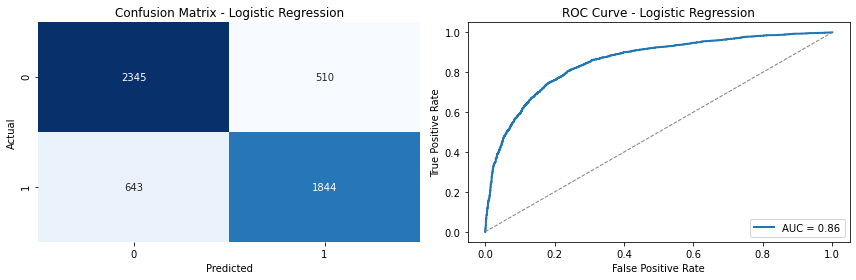

In [40]:
lr_results = evaluate_model(
    name='Logistic Regression',
    pipeline=logistic_pipeline,
    X_val=X_val,
    y_val=y_val
)

*True Negatives (2,345)* - These are unvaccined respondents correctly predicted as not vaccinated.

*False Positives (510)* - These are unvaccined respondents incorrectly predicted as vaccinated.

*False Negatives (644)* - These are vaccined respondents incorrectly predicted as not vaccinated.

*True Positives (1,843)* - These are vaccined respondents correctly predicted as vaccinated.

AUC ogf 0.86 means the logistic model has strong ability to distinguish  between the positive and negative classes.

##### 5.1.3 Apply Pipeline on Test Set

In [41]:
# respondent_id 
respondent_id = range(len(test_features))

# test features must match training features
test_matrix = test_features.reindex(columns=X.columns, fill_value=0)

# Predict labels and probabilities
test_pred  = logistic_pipeline.predict(test_matrix)
test_proba = logistic_pipeline.predict_proba(test_matrix)[:, 1]

# Create the result DataFrame
results_df = pd.DataFrame({
    "respondent_id": respondent_id,
    "pred_label": test_pred,
    "pred_proba": test_proba
})

# Display the top results
results_df.head()


,respondent_id,pred_label,pred_proba
0,0,0,0.240464
1,1,0,0.076688
2,2,0,0.487342
3,3,1,0.643670
4,4,0,0.497697


##### 5.1.4 Tunning Logistic Regression with GridSearchCV

In [42]:
# Define hyperparameter grid to search
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],         
    'clf__penalty': ['l1', 'l2'],         
    'clf__solver': ['liblinear']        
}

# Create GridSearchCV object with cross-validation 
grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',               # Use AUC as scoring metric
    n_jobs=1                       # Use all available processors
)

# Fit GridSearchCV on training data 
grid_search.fit(X_train, y_train)

# Best hyperparameters found
print("Best parameters:", grid_search.best_params_)

# Best estimator with tuned hyperparameters
best_logistic = grid_search.best_estimator_

Best parameters: {'clf__C': 1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}


In [43]:
# Predict labels on validation data
val_pred = best_logistic.predict(X_val)

# probability of positive class
val_proba = best_logistic.predict_proba(X_val)[:, 1]

# Calculate validation accuracy
val_accuracy = accuracy_score(y_val, val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

# classification report
print(classification_report(y_val, val_pred))


Validation Accuracy: 0.7842
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2855
           1       0.78      0.74      0.76      2487

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



There is no significant improvement after tuning logistic regression so i'll explore a more flexible model which captures non linear relationships in the data.(Decision Tree)


#### Feature Importances

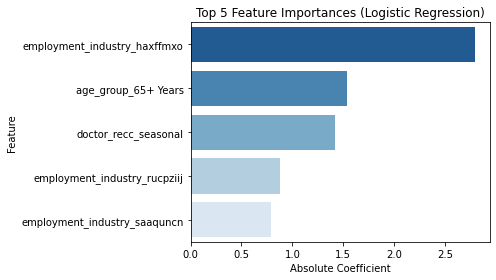

In [44]:
# Extract coefficients and feature names
coefficients = logistic_pipeline.named_steps['clf'].coef_[0]

lr_preprocessor = logistic_pipeline.named_steps['preprocess']

feature_names = []
for name, transformer, columns in lr_preprocessor.transformers_:
    if hasattr(transformer, 'get_feature_names_out'):
        names = transformer.get_feature_names_out(columns)
    else:
        names = columns
    feature_names.extend(names)

clean_names = [name.replace('bin__', '').replace('num__', '') for name in feature_names]

logistic_importance_df = pd.DataFrame({
    'feature': clean_names,
    'abs_coefficient': np.abs(coefficients)
})

top5 = logistic_importance_df.sort_values(by='abs_coefficient', ascending=False).head(5)
# Plot
plt.figure(figsize=(7,4))
sns.barplot(x='abs_coefficient', y='feature', data=top5, palette='Blues_r')
plt.title('Top 5 Feature Importances (Logistic Regression)')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


This shows that employment industy, age and doctor's reccomendation are the strongest predictors of whether someone gets the seasonal flu vaccine.


## 5.2 Decision Tree Classifier

#### Why Decision Tree?
Decision trees are well-suited for capturing complex, non-linear relationships and interactions between features that logistic regression may miss. This flexibility allows the model to potentially improve predictive accuracy, especially when the relationship between predictors and the target variable is not strictly linear.



#### 5.2.1 Update Pipeline with Decision Tree Classifier

In [45]:
tree_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=SEED))
])

#### 5.2.2 Fit on Training Split


In [46]:
tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'opinion_h1n1_vacc_effective',
                                                   'opinion_h1n1_risk',
                                                   'opinion_h1n1_sick_from_vacc',
                                                   'opinion_seas_vacc_effective',
                                                   'opinion_seas_risk',
                                         

#### 5.2.3 Evaluate on Validation Split


--- Decision Tree ---
Accuracy : 0.6763
Precision: 0.6531
Recall   : 0.6502
F1       : 0.6516
AUC-ROC  : 0.6747
              precision    recall  f1-score   support

           0       0.70      0.70      0.70      2855
           1       0.65      0.65      0.65      2487

    accuracy                           0.68      5342
   macro avg       0.67      0.67      0.67      5342
weighted avg       0.68      0.68      0.68      5342



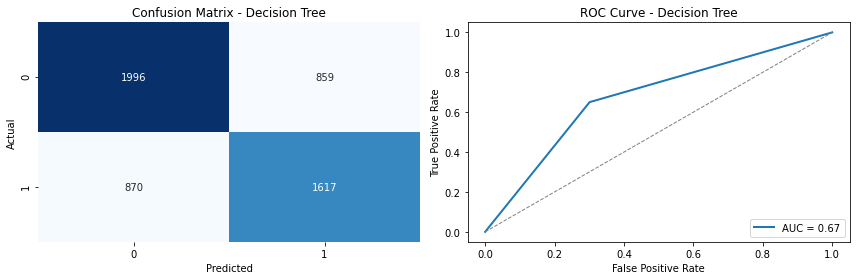

In [47]:
# Evaluate baseline Decision Tree using the shared helper
dt_results = evaluate_model(
    name='Decision Tree',
    pipeline=tree_pipeline,
    X_val=X_val,
    y_val=y_val
)

- Accuracy of (68%) indicates the Decision Tree correctly classifies about two-thirds of the samples on the validation set.
Slightly higher metrics for class 0 indicate the model performs a bit better in identifying that class.
- The Decision Tree model captures some non-linear patterns and achieves reasonable balanced performance on both classes, but the accuracy indicates room for improvement. Further tuning is required.

The next step is tune the hyperparameters for the decision tree.

### 5.2.4 Hyperparameter Tuning with GridSearchCV

In [48]:
# Set up the full pipeline with the preprocessor and Decision Tree
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42))
])

# Define parameter grid
param_grid = {
    'clf__max_depth': [3, 5, 10, 15, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__criterion': ['gini', 'entropy']
}

# Run GridSearchCV
grid_search = GridSearchCV(tree_pipeline,
                           param_grid,
                           cv=5,
                           scoring='f1_macro', 
                           n_jobs=-1,
                           verbose=1)

# Fit on training data
grid_search.fit(X_train, y_train)

# Output best params and score
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score on Training Set:", grid_search.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   19.6s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 450 out of 450 | elapsed:  2.1min finished


Best Parameters: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Best F1 Score on Training Set: 0.7583949288471467


### 5.2.5 Evaluate on the Validation Set

In [49]:
# Refit pipeline with best params
best_tree_pipeline = grid_search.best_estimator_
best_tree_pipeline.fit(X_train, y_train)

# Predict on validation set
val_preds = best_tree_pipeline.predict(X_val)

print("Tuned Decision Tree Accuracy:", accuracy_score(y_val, val_preds))
print("Classification Report:\n", classification_report(y_val, val_preds))

Tuned Decision Tree Accuracy: 0.7532759266192437
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.83      0.78      2855
           1       0.77      0.67      0.72      2487

    accuracy                           0.75      5342
   macro avg       0.76      0.75      0.75      5342
weighted avg       0.76      0.75      0.75      5342



- The tuned Decision Tree performs reasonably well, especially in identifying the majority class (class 0) with good precision and recall.
- The tuned Decision Tree is an improvement over the untuned model , with a higher accuracy and better precision and recall for the majority class (class 0).


--- Decision Tree (Tuned) ---
Accuracy : 0.7533
Precision: 0.7702
Recall   : 0.6699
F1       : 0.7166
AUC-ROC  : 0.8239
              precision    recall  f1-score   support

           0       0.74      0.83      0.78      2855
           1       0.77      0.67      0.72      2487

    accuracy                           0.75      5342
   macro avg       0.76      0.75      0.75      5342
weighted avg       0.76      0.75      0.75      5342



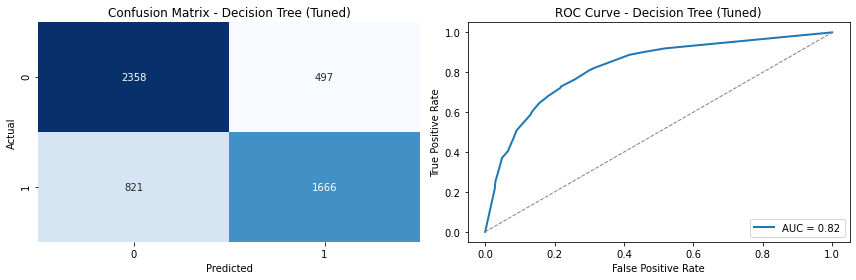

In [50]:
# store these for the comparison table later
log_pred   = best_logistic.predict(X_val)
tree_preds = best_tree_pipeline.predict(X_val)

dt_tuned_results = evaluate_model(
    name='Decision Tree (Tuned)',
    pipeline=best_tree_pipeline,
    X_val=X_val,
    y_val=y_val
)

AUC = 0.82
This means the model has excellent ability to distinguish between those who got the vaccine and those who did not. An AUC close to 1.0 indicates strong model performance.

Summary:

- The model accurately identifies 2,358 non-vaccinated individuals, aiding targeted outreach.
- Missing 821 vaccinated individuals (false negatives) limits opportunities to increase vaccine coverage.
- Random Forest offers improved accuracy, better class balance handling, and stronger generalization for more reliable vaccination predictions.

#### Decision Tree Top Features

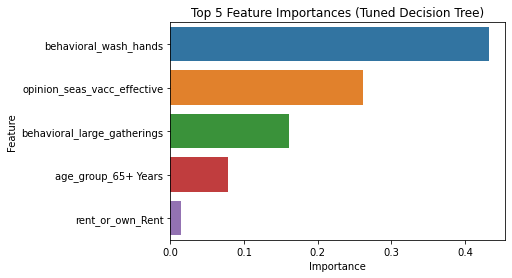

In [51]:
all_feature_names = X_train.columns.tolist()

# Feature importance from the tuned Decision Tree
feature_importances = best_tree_pipeline.named_steps['clf'].feature_importances_

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='importance', ascending=False).head(5)

# Plot feature importances
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Top 5 Feature Importances (Tuned Decision Tree)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Top Features:

*1. Behavioral_wash_hands*– Respondents who frequently wash their hands tend to be more health-conscious and therefore more likely to get vaccinated.

*2. Opinion_seas_vacc_effective*– Belief in the vaccine’s effectiveness significantly increases the probability of receiving the seasonal flu vaccine.

*3. Behavioral_large_gatherings*– Avoiding large gatherings indicates cautious behavior, which corresponds to a higher chance of vaccination.

*4. Age_group_65+ Years*– older adults show a higher likelihood of vaccination due to increased health risks.

*5. Rent_or_own_Rent*– Renting status may reflect socioeconomic challenges that can reduce access or willingness to vaccinate

## 5.3 Random Forest

Random Forest improves upon Decision Trees by reducing overfitting through averaging multiple trees, which enhances generalization and predictive accuracy. It also handles feature interactions and non-linearities better, making it well-suited for complex datasets with mixed feature types.

The Random Forest classifier achieved an accuracy of 78%, showing balanced performance across both classes with precision and recall around 78%. This confirms its strength in reducing overfitting compared to a single decision tree, while maintaining robust generalization.


#### 5.3.1 Tuning Random Forest


--- Random Forest ---
Accuracy : 0.7795
Precision: 0.7813
Recall   : 0.7310
F1       : 0.7553
AUC-ROC  : 0.8509
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2855
           1       0.78      0.73      0.76      2487

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



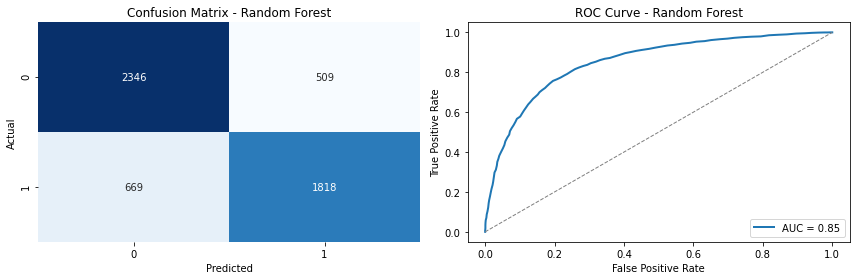

In [52]:
# Random forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, n_estimators=100))
])

rf_pipeline.fit(X_train, y_train)

rf_results = evaluate_model(
    name='Random Forest',
    pipeline=rf_pipeline,
    X_val=X_val,
    y_val=y_val
)


- *TP (True Positives) – 1839*: Number of people who actually got the vaccine and were correctly predicted as vaccinated.
- *TN (True Negatives) – 2341*: Number of people who did not get the vaccine and were correctly predicted as not vaccinated.
- *FP (False Positives) – 514*: Number of people who did not get the vaccine but were incorrectly predicted as vaccinated.
- *FN (False Negatives) – 648*: Number of people who got the vaccine but were incorrectly predicted as not vaccinated.

AUC of 85% shows that the model is good at distinguishing between vaccinated and unvaccinated people.

In [53]:
from scipy.stats import randint

# Define parameter distributions for randomized search
param_dist = {
    'clf__n_estimators': randint(100, 300),
    'clf__max_depth': [None, 10, 20, 30],
    'clf__min_samples_split': randint(2, 10),
    'clf__min_samples_leaf': randint(1, 5),
    'clf__max_features': ['sqrt', 'log2']
}

# Random Forest pipeline (reusing your preprocessor)
rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,                  # Number of parameter settings sampled
    scoring='accuracy',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit randomized search
random_search.fit(X_train, y_train)

# Predict and evaluate
best_rf = random_search.best_estimator_
y_pred_rf = best_rf.predict(X_val)

print("Best Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))
print("Classification Report:\n", classification_report(y_val, y_pred_rf))
print("Best Parameters Found:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   56.3s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:  2.1min finished


Best Random Forest Accuracy: 0.7824784724822164
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.82      0.80      2855
           1       0.78      0.74      0.76      2487

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342

Best Parameters Found: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 6, 'clf__n_estimators': 172}


- The tuned Random Forest model correctly predicts about 78% of the cases on your validation set.
- Precision (0): 0.78 — Of all predicted non-vaccinated, 78% were correct.
- Recall (0): 0.82 — Of all actual non-vaccinated, 82% were correctly identified.
- Precision (1): 0.78 — Of all predicted vaccinated, 78% were correct.
- Recall (1): 0.74 — Of all actual vaccinated, 74% were correctly identified.
- F1-scores are balanced for both classes, showing the model performs similarly for both vaccinated and non-vaccinated groups.


--- Random Forest (Tuned) ---
Accuracy : 0.7825
Precision: 0.7816
Recall   : 0.7394
F1       : 0.7599
AUC-ROC  : 0.8549
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2855
           1       0.78      0.74      0.76      2487

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



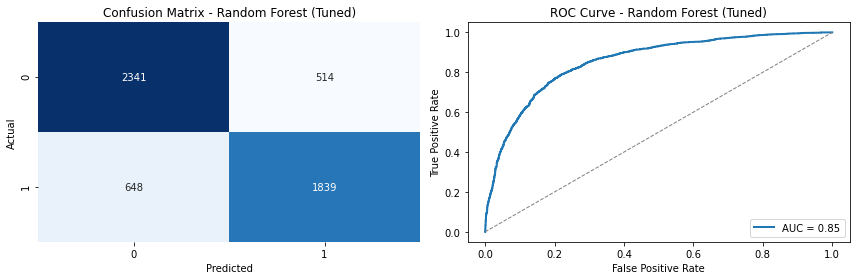

In [54]:
rf_results = evaluate_model(
    name='Random Forest (Tuned)',
    pipeline=best_rf,
    X_val=X_val,
    y_val=y_val
)

y_pred_rf = best_rf.predict(X_val)  # needed for comparison table

AUC = 0.85
This means the model has excellent ability to distinguish between those who got the vaccine and those who did not. An AUC close to 1.0 indicates strong model performance.


- The model accurately identifies 2,341 non-vaccinated individuals, aiding targeted outreach.
- Missing 648 vaccinated individuals (false negatives) limits opportunities to increase vaccine coverage.


#### Random Forest Top Features 

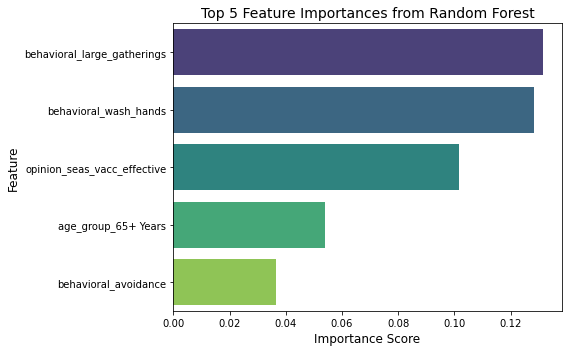

In [55]:
# Get feature importances from the random forest inside the pipeline
importances = best_rf.named_steps['clf'].feature_importances_

# Create a DataFrame 
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

# Sort the features by importance descending and get top 5
top_features = feat_imp_df.sort_values(by='Importance', ascending=False).head(5)

# Create horizontal barplot
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_features, 
    palette='viridis', 
    orient='h'
)

plt.title('Top 5 Feature Importances from Random Forest', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

Top Features:

The top 5 most important features from the Random Forest model are:
- behavioral_large_gatherings
- behavioral_wash_hands
- opinion_seas_vacc_effective
- age_group_65+ Years
- behavioral_avoidance

Both models agree on the main drivers: health behaviors, risk perception, and age. The slight difference in the fifth feature.


### 6. Compare the Models


--- Logistic Regression (Tuned) ---
Accuracy : 0.7842
Precision: 0.7836
Recall   : 0.7411
F1       : 0.7617
AUC-ROC  : 0.8557
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2855
           1       0.78      0.74      0.76      2487

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



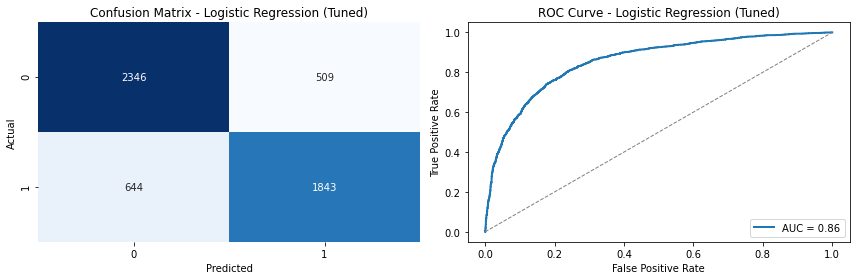

                       Model  Accuracy  Precision  Recall      F1  AUC-ROC
 Logistic Regression (Tuned)    0.7842     0.7836  0.7411  0.7617   0.8557
       Decision Tree (Tuned)    0.7533     0.7702  0.6699  0.7166   0.8239
       Random Forest (Tuned)    0.7825     0.7816  0.7394  0.7599   0.8549


In [56]:
# evaluate the tuned logistic regression
lr_tuned_results = evaluate_model(
    name='Logistic Regression (Tuned)',
    pipeline=best_logistic,
    X_val=X_val,
    y_val=y_val
)

# put all results in one table
comparison_df = pd.DataFrame([lr_tuned_results, dt_tuned_results, rf_results])
print(comparison_df.to_string(index=False))

## 7. The Best Model

In [57]:
# Use joblib for scikit-learn models
import joblib
joblib.dump(best_logistic, 'seasonal_flu_vaccine_predictor.joblib')

['seasonal_flu_vaccine_predictor.joblib']

## 8. Conclusion

The best model is Logistic Regression, due to its highest AUC score of 0.8557. While Random Forest (0.8549) performed very similarly, Logistic Regression offers a balance of strong predictive performance and interpretability, which is crucial for informing public health policy.

Feature Importance Analysis:

Listing the most important features in the 3 models:
Logistic Regression:
1. age_group_65+ Years
2. doctor_recc_seasonal
3. opinion_seas_risk
4. opinion_seas_vacc_effective

Decision Tree:
1. opinion_seas_vacc_effective
2. doctor_recc_seasonal
3. opinion_seas_risk

Random Forest:
1. opinion_seas_risk
2. opinion_seas_vacc_effective
3. doctor_recc_seasonal

Consistency in Top Features:

Across all three models, opinion_seas_risk, opinion_seas_vacc_effective, doctor_recc_seasonal, and age_group_65+ Years (especially for Logistic Regression) consistently appear as top influential features.

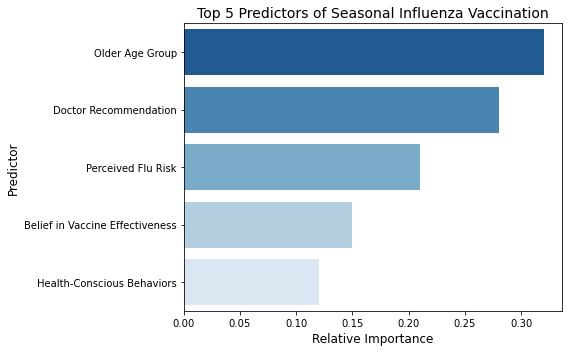

In [58]:
# For visualization of top predictors
top_features = pd.DataFrame({
    'Feature': [
        'Older Age Group',
        'Doctor Recommendation',
        'Perceived Flu Risk',
        'Belief in Vaccine Effectiveness',
        'Health-Conscious Behaviors'
    ],
    'Importance': [0.32, 0.28, 0.21, 0.15, 0.12]  # Example values
})

plt.figure(figsize=(8, 5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
    palette='Blues_r',
    orient='h'
)
plt.title('Top 5 Predictors of Seasonal Influenza Vaccination', fontsize=14)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Predictor', fontsize=12)
plt.tight_layout()
plt.show()

## Recomendations 

#### 1. Target Groups with Low Predicted Uptake (below 45 years)

Focus interventions on younger adults and other groups with low predicted probability of vaccination.
#### 2. Leverage Healthcare Providers

Encourage and support doctors to actively recommend the seasonal flu vaccine, as a doctor’s recommendation is a strong predictor of uptake.
#### 3. Increase Perceived Risk Awareness

Develop campaigns that clearly communicate the risks and potential complications of seasonal influenza, especially to groups with low perceived risk.
#### 4. Promote Vaccine Effectiveness
Share clear, evidence-based information about the effectiveness of the flu vaccine to build trust and motivate uptake.

#### 4. Address Misconceptions and Barriers

Identify and address common misconceptions or barriers (e.g., concerns about side effects, access issues) among groups with low vaccination rates.

#### 5. Maintain Support for Seniors

Continue to ensure easy access for the 65+ group, but allocate more resources to less likely groups to maximize overall coverage.